Projet python, Clémentine, Louise et Hugo
Notre sujet s'intéresse à la question suivante : Dans quelle mesure la météo et le prix du carburant influencent-ils l’usage du réseau STAR en 2025 ?


import de nos données : données star du réseau rennais et données météos - données carburant ? 

https://data.explore.star.fr/explore/dataset/tco-billettique-star-frequentation-agregee-td/table/?dataChart=eyJxdWVyaWVzIjpbeyJjaGFydHMiOlt7ImFsaWduTW9udGgiOnRydWUsInR5cGUiOiJjb2x1bW4iLCJmdW5jIjoiU1VNIiwieUF4aXMiOiJmcmVxdWVudGF0aW9uIiwic2NpZW50aWZpY0Rpc3BsYXkiOnRydWUsImNvbG9yIjoicmFuZ2UtU2V0MSJ9XSwieEF4aXMiOiJkYXRlIiwibWF4cG9pbnRzIjoiIiwidGltZXNjYWxlIjoiZGF5Iiwic29ydCI6IiIsInNlcmllc0JyZWFrZG93blRpbWVzY2FsZSI6IiIsInNlcmllc0JyZWFrZG93biI6ImNhdGVnb3JpZWxpZ25lIiwic3RhY2tlZCI6Im5vcm1hbCIsImNvbmZpZyI6eyJkYXRhc2V0IjoidGNvLWJpbGxldHRpcXVlLXN0YXItZnJlcXVlbnRhdGlvbi1hZ3JlZ2VlLXRkIiwib3B0aW9ucyI6e319fV0sImRpc3BsYXlMZWdlbmQiOnRydWUsImFsaWduTW9udGgiOnRydWV9


In [1]:
from src.merge import build_dataset

df = build_dataset()

df.head()

Téléchargement des données carburant 2025...
Série quotidienne : 365 jours couverts
Carburants disponibles : ['E10', 'E85', 'GPLc', 'Gazole', 'SP95', 'SP98']


,date,frequentation_metro,frequentation_bus,frequentation_bus_even,frequentation_pr,temperature,precipitation,E10,E85,GPLc,Gazole,SP95,SP98
0,2025-01-01,67765.61347,12278.82352,0,789.47368,10.075000,0.3,1.705375,0.754333,0.921250,1.648750,NaN,1.807500
1,2025-01-02,136025.23386,47476.47058,0,3359.07121,6.891667,17.9,1.700889,0.754333,0.916000,1.643889,NaN,1.802778
2,2025-01-03,151349.80001,56222.35293,0,3741.73375,2.379167,0.0,1.705462,0.788750,0.916000,1.651692,1.740,1.805692
3,2025-01-04,116959.09917,41338.82353,0,2665.26316,1.620833,9.4,1.721700,0.765750,0.916000,1.668300,NaN,1.817444
4,2025-01-05,69976.20538,17065.88235,0,602.10526,12.320833,14.5,1.721375,0.764667,0.918667,1.668444,1.747,1.821333


In [2]:
print(df.shape)
print(df.dtypes)


(365, 13)
date                      datetime64[ns]
frequentation_metro              float64
frequentation_bus                float64
frequentation_bus_even             int64
frequentation_pr                 float64
temperature                      float64
precipitation                    float64
E10                              float64
E85                              float64
GPLc                             float64
Gazole                           float64
SP95                             float64
SP98                             float64
dtype: object


In [3]:
print(df.describe())
print(df.isnull().sum())

                                date  frequentation_metro  frequentation_bus  \
count                            365           365.000000         365.000000   
mean   2025-07-01 23:59:59.999999744        176172.391339       64631.983174   
min              2025-01-01 00:00:00          1820.436100         641.176480   
25%              2025-04-02 00:00:00        123449.018900       45317.647060   
50%              2025-07-02 00:00:00        181607.704040       67849.411760   
75%              2025-10-01 00:00:00        236701.700460       91231.764700   
max              2025-12-31 00:00:00        272300.914350      102116.470590   
std                              NaN         65665.808997       28123.636602   

       frequentation_bus_even  frequentation_pr  temperature  precipitation  \
count                   365.0        362.000000   365.000000     365.000000   
mean                      0.0       3241.340848    12.857283       2.432329   
min                       0.0         54.7

In [4]:
from src.stat_des import impute_carburant

df = impute_carburant(df)

Valeurs manquantes AVANT imputation :
E10         0
E85         3
GPLc        0
Gazole      0
SP95      265
SP98        0
dtype: int64

Valeurs manquantes APRÈS imputation :
E10       0
E85       0
GPLc      0
Gazole    0
SP95      0
SP98      0
dtype: int64


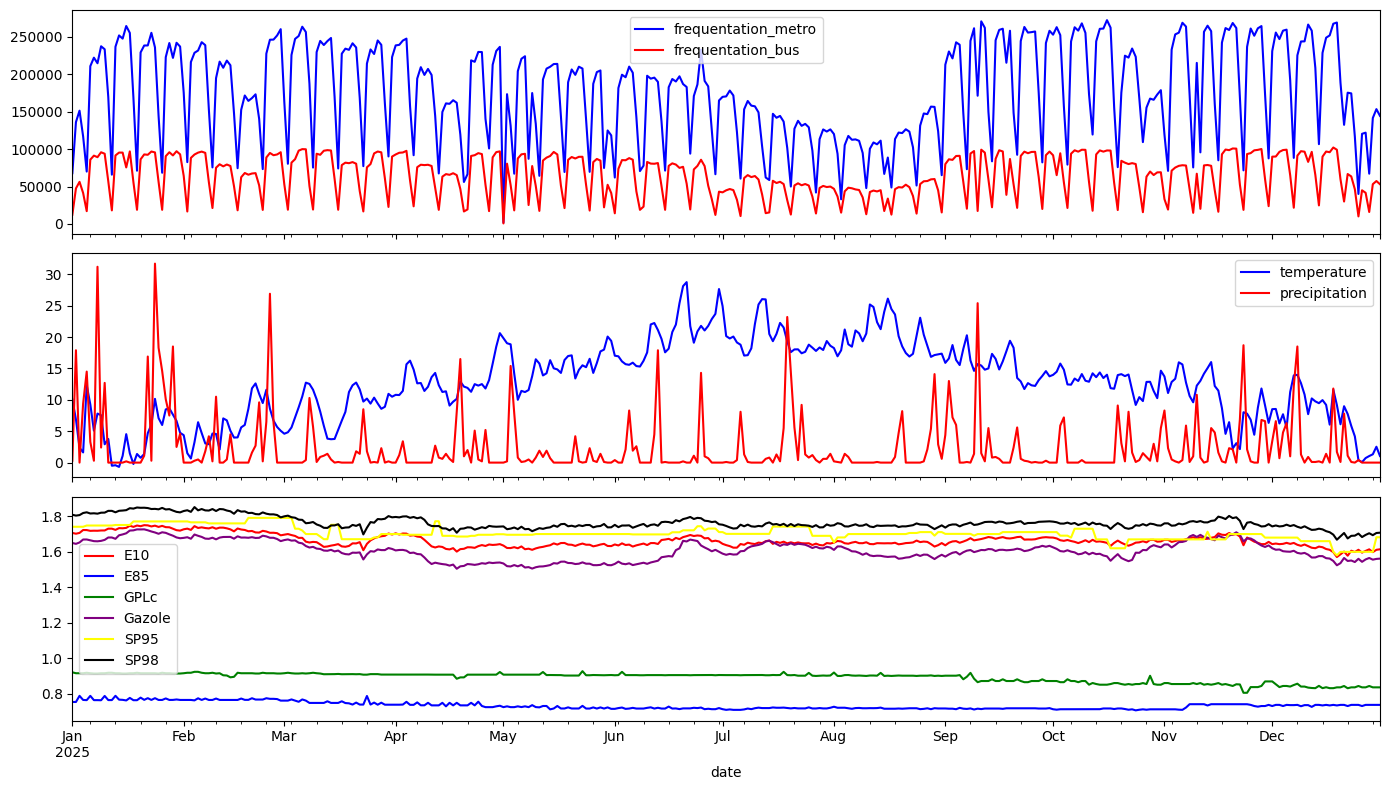

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)


df.plot(x='date', y='frequentation_metro', kind='line', ax=ax1, color='blue')
df.plot(x='date', y='frequentation_bus',   kind='line', ax=ax1, color='red')

df.plot(x='date', y='temperature', kind='line', ax=ax2, color='blue')
df.plot(x='date', y='precipitation',   kind='line', ax=ax2, color='red')

df.plot(x='date', y='E10',   kind='line', ax=ax3, color='red')
df.plot(x='date', y='E85',   kind='line', ax=ax3, color='blue')
df.plot(x='date', y='GPLc',   kind='line', ax=ax3, color='green')
df.plot(x='date', y='Gazole',   kind='line', ax=ax3, color='purple')
df.plot(x='date', y='SP95',   kind='line', ax=ax3, color='yellow')
df.plot(x='date', y='SP98',   kind='line', ax=ax3, color='black')

plt.tight_layout()
plt.show()

à reformuler:
Courbe qui forme des semaines avec baisse de fréquentation durant les vacances scolaire (logique)

Météo bah logique aussi
et tout les carburant bouge à peu près pareil, faire courbe de tendance?

## 3 — Analyse des corrélations

Avant de construire le modèle de régression, on examine les relations linéaires entre les variables explicatives (météo, carburant) et les cibles (fréquentation).  

Deux visualisations complémentaires :
- **Heatmap triangulaire** — vue globale de toutes les corrélations entre variables
- **Bar chart des top corrélations** — zoom sur les variables les plus liées à la fréquentation cible

In [6]:
from src.stat_des import plot_correlation_heatmap, plot_top_correlations

### 3.1 Heatmap — toutes les variables

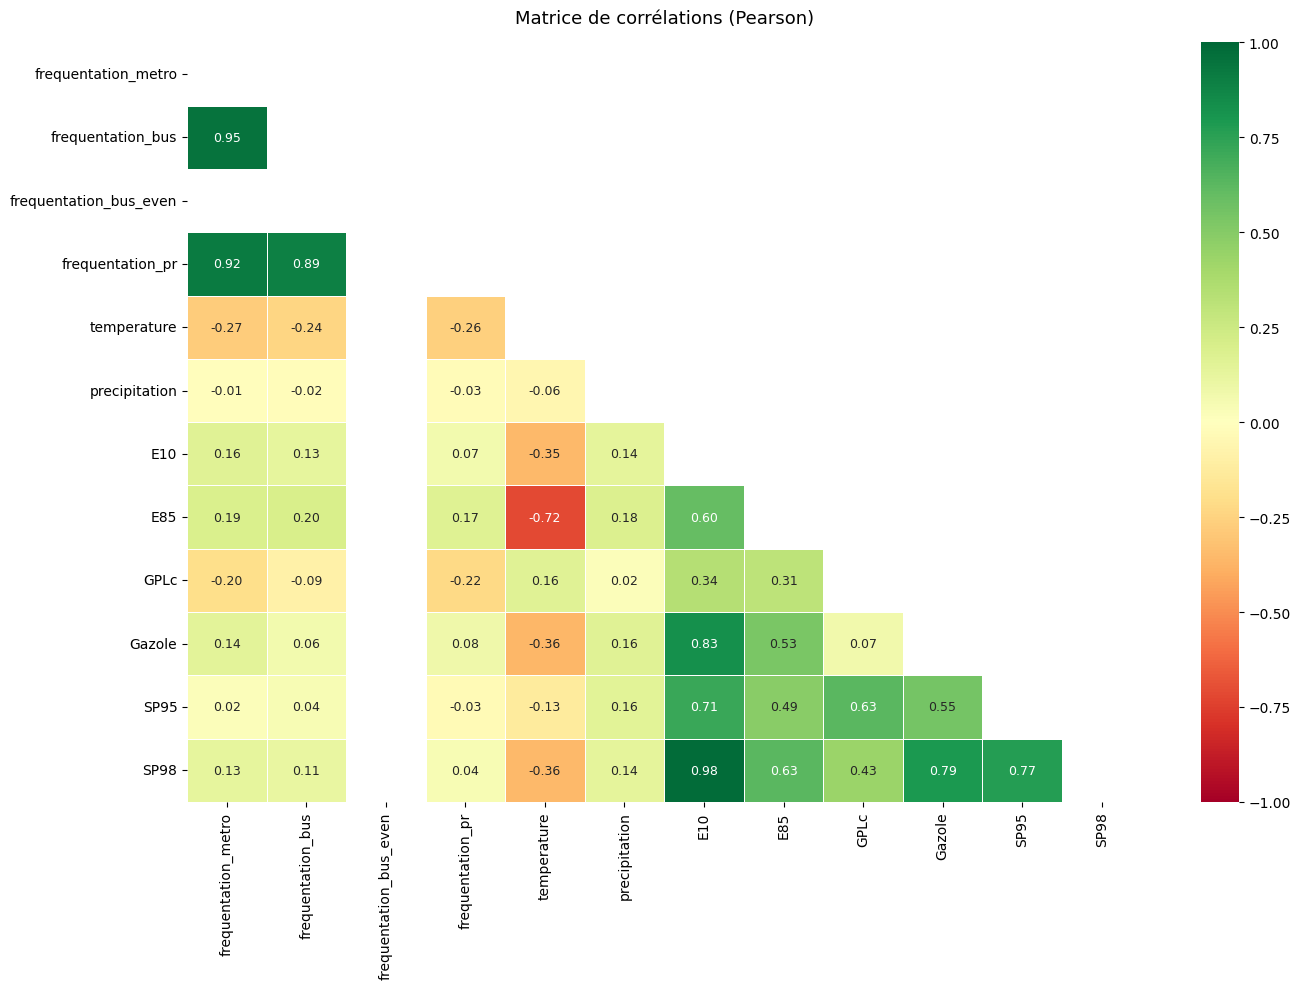

In [7]:
corr = plot_correlation_heatmap(df)

### 3.2 Top corrélations avec la fréquentation

On identifie les variables les plus corrélées avec la ligne principale (`frequentation_metro`).  
Changer `target` pour analyser une autre ligne du réseau.

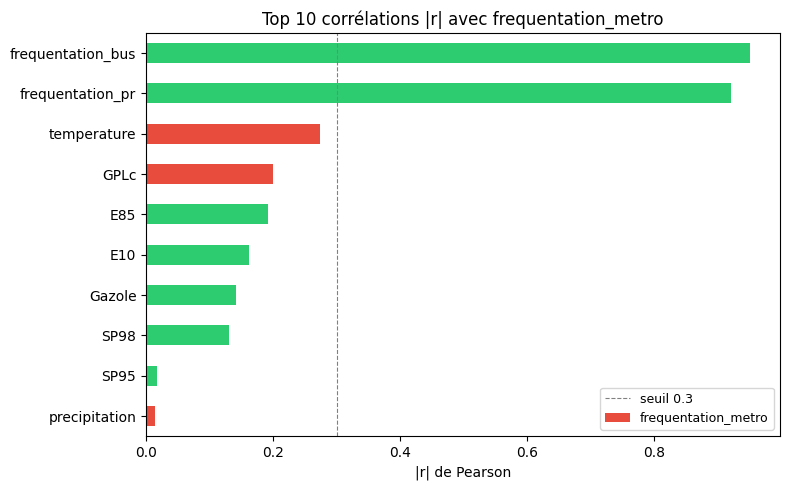


Valeurs complètes (avec signe) pour frequentation_metro :

frequentation_bus    0.951
frequentation_pr     0.921
temperature         -0.274
GPLc                -0.200
E85                  0.192
E10                  0.162
Gazole               0.142
SP98                 0.130
SP95                 0.018
precipitation       -0.014


In [8]:
plot_top_correlations(corr, df, target='frequentation_metro', top_n=10)

*inserer une analyse de tout ca*

## 4 — Modélisation : Arbre de décision

On entraîne deux modèles indépendants (**métro** et **bus**) à base d'arbre de décision (`DecisionTreeRegressor`).  
Les hyperparamètres `max_depth`, `min_samples_split` et `min_samples_leaf` sont optimisés par **GridSearchCV** avec une validation croisée temporelle (`TimeSeriesSplit`).

In [9]:
from src.regression import (
    build_features, stratified_split, run_grid_search,
    evaluate_model, compare_metrics, predict_frequentation
)

### 4.1 Feature engineering

On enrichit le DataFrame avec les features temporelles : jour de la semaine, mois, numéro de semaine, week-end et jour férié (calendrier français).

In [10]:
df = build_features(df)

Features temporelles ajoutées :
      date  day_of_week  month  week_number  is_weekend  is_holiday
2025-01-01            2      1            1           0           1
2025-01-02            3      1            1           0           0
2025-01-03            4      1            1           0           0
2025-01-04            5      1            1           1           0
2025-01-05            6      1            1           1           0
2025-01-06            0      1            2           0           0
2025-01-07            1      1            2           0           0


### 4.2 Split 

découpage qui mets à peu pres le même nombre de jour par mois (à reformuler)

In [11]:

X_train, X_test, y_train_metro, y_test_metro, y_train_bus, y_test_bus, df_test = stratified_split(df)

Split stratifié par mois : 292 jours train / 73 jours test
  Mois représentés dans le test : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


### 4.3 Grid search — Métro

Recherche des meilleurs hyperparamètres pour le modèle métro avec `TimeSeriesSplit(n_splits=5)`.

In [12]:
gs_metro = run_grid_search(X_train, y_train_metro, target_name='frequentation_metro')


Grid search pour : frequentation_metro
Fitting 5 folds for each of 80 candidates, totalling 400 fits
  Meilleurs paramètres : {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
  MAE CV (train)       : 23,133 voyageurs


### 4.4 Grid search — Bus

In [13]:
gs_bus = run_grid_search(X_train, y_train_bus, target_name='frequentation_bus')


Grid search pour : frequentation_bus
Fitting 5 folds for each of 80 candidates, totalling 400 fits
  Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
  MAE CV (train)       : 8,460 voyageurs


### 4.5 Évaluation sur le jeu de test

On calcule **MAE**, **RMSE** et **R²** sur les données non vues, et on visualise les prédictions vs les valeurs réelles.


── Évaluation frequentation_metro ──────────────────
  MAE  :       29,412 voyageurs
  RMSE :       41,370 voyageurs
  R²   :       0.5781


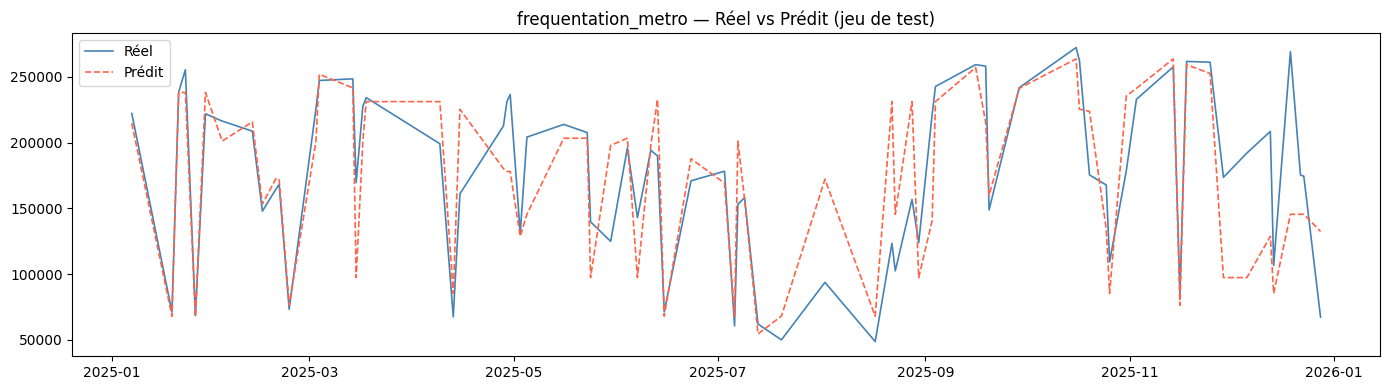

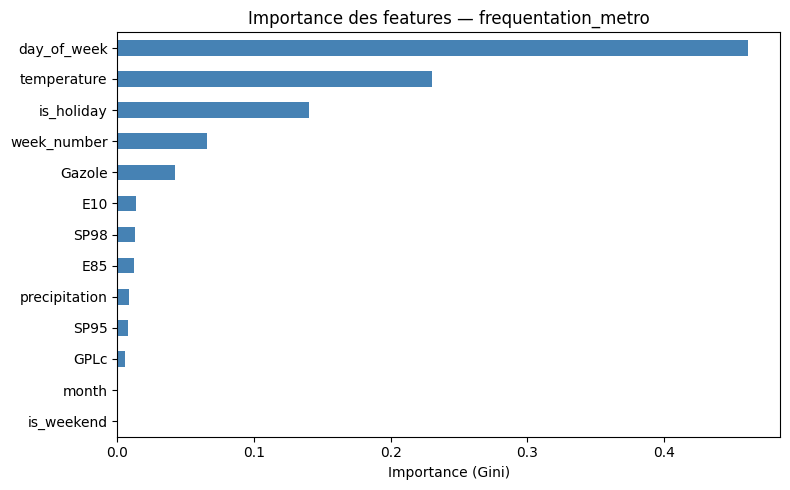


── Évaluation frequentation_bus ──────────────────
  MAE  :        9,221 voyageurs
  RMSE :       13,106 voyageurs
  R²   :       0.7760


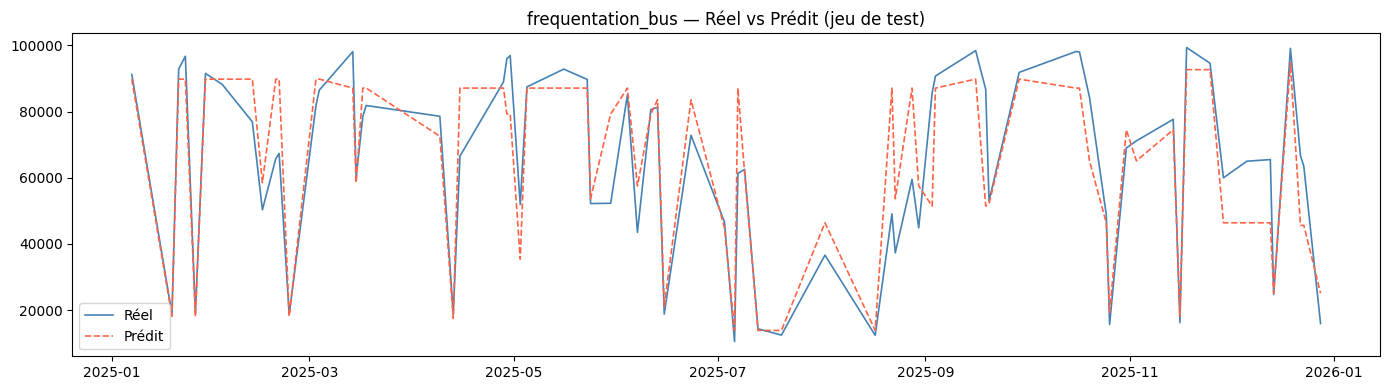

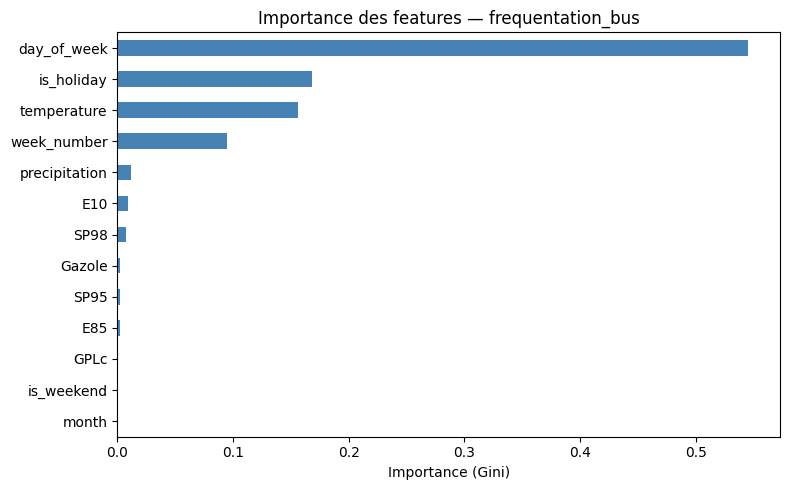

In [14]:
metrics_metro = evaluate_model(gs_metro, X_test, y_test_metro, 'frequentation_metro', df_test)
metrics_bus   = evaluate_model(gs_bus,   X_test, y_test_bus,   'frequentation_bus',   df_test)

In [15]:
compare_metrics(metrics_metro, metrics_bus)


── Récapitulatif des métriques ───────────────
           MAE     RMSE      R2
Metro  29412.0  41370.0  0.5781
Bus     9221.0  13106.0  0.7760


### 4.6 Prédiction

Fonction finale de prédiction : renseigne la date, les conditions météo et les prix carburant pour obtenir une estimation de fréquentation.  
Faire teste avec date du jour
Changer `ligne='metro'` en `ligne='bus'` pour la prédiction bus.

In [16]:
predict_frequentation(
    date          = '2025-06-15',
    temperature   = 22.0,
    precipitation = 0.0,
    E10           = 1.72,
    E85           = 0.79,
    GPLc          = 0.92,
    Gazole        = 1.65,
    SP95          = 1.75,
    SP98          = 1.82,
    ligne         = 'metro',
    model_metro   = gs_metro,
    model_bus     = gs_bus
)


Prédiction fréquentation metro le 2025-06-15 :
  Jour férié : non | Week-end : oui
  → 88,800 voyageurs estimés


np.float64(88799.89769)